# Lossless Preparation of Periodic Signal by Fourier Transformation

This example corresponds to a special case in which the signal possesses an exactly sparse Fourier representation. Consequently, no thresholding is required and the reconstruction remains lossless.

## Imports

In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from hybridqsp.transforms import dft, idft

from hybridqsp.thresholding import (
    top_k_threshold,
    magnitude_threshold
)

from hybridqsp.metrics import (
    state_fidelity,
    trace_distance
)

## Signal Generation
We construct a synthetic signal composed of multiple sinusoidal components in order to study sparse Fourier representations.

In [10]:
# ============================================================
# Parameters
# ============================================================

n = 10
N = 2**n

np.random.seed(42)

t = np.linspace(-1, 1, N)
x = np.linspace(-5, 5, N)


# ============================================================
# Helper
# ============================================================

def normalize(signal):
    signal = np.asarray(signal, dtype=float)
    signal /= np.linalg.norm(signal)
    return signal


# ============================================================
# Candidate 1
# Random sparse Fourier coefficients
# (Ideal for DS-QSP using DFT)
# ============================================================

d = 30

target_f = np.zeros(N, dtype=complex)

idx = np.random.choice(N, d, replace=False)

target_f[idx] = np.random.randn(d) + 1j*np.random.randn(d)

fourier_sparse = np.fft.ifft(target_f).real
x = normalize(fourier_sparse)

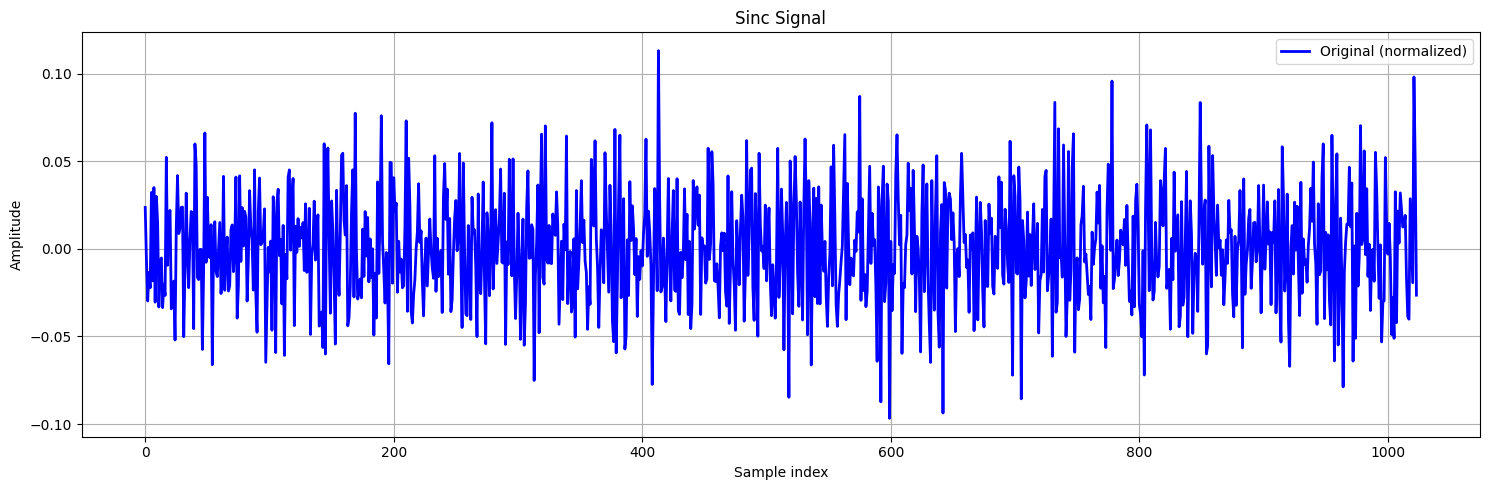

In [11]:
plt.figure(figsize=(15, 5))
plt.plot(x, label="Original (normalized)", lw=2, color="blue")

plt.title(f"Sinc Signal")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()

## Fourier Transform
The signal is transformed into the frequency domain using the unitary Discrete Fourier Transform (DFT).

In [12]:
X = dft(x)

In [14]:
freqs = np.fft.fftfreq(len(X), d=1/1024)

### Visualization of Frequency Domain

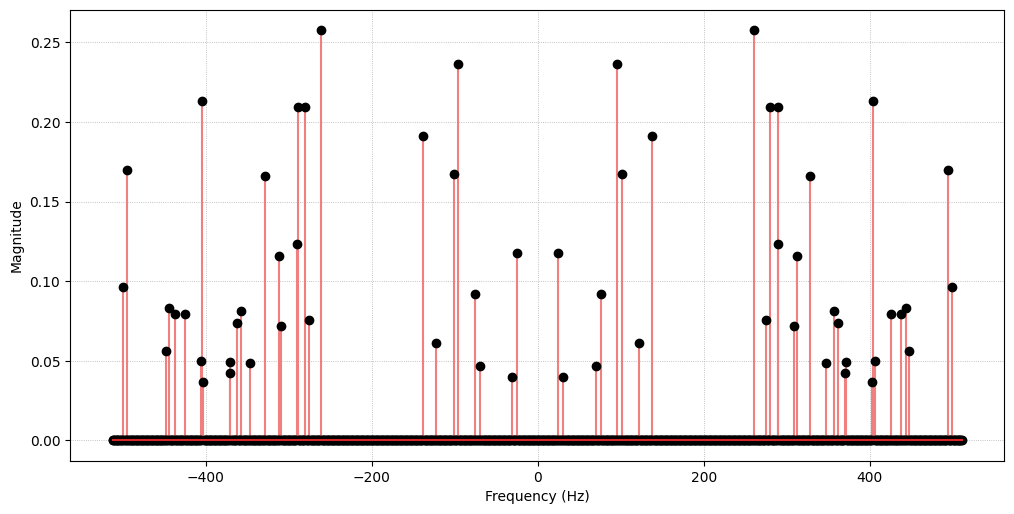

In [15]:
plt.figure(figsize=(10,5))  # smaller height for paper

# Plot original 
plt.stem(freqs, np.abs(X), linefmt="lightcoral", markerfmt="ko")
# Labels and grid
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True, linestyle=':', linewidth=0.6)

# Tidy up layout
plt.tight_layout(pad=0.2)
plt.show()

## Normalization
Due to floating-point numerical precision, the Fourier representation contains negligible coefficients with magnitudes close to machine precision. These coefficients are removed using a numerical tolerance in order to recover the exact sparse structure of the signal.

In [16]:
tol = 1e-10

X_clean = X.copy()

X_clean[np.abs(X_clean) < tol] = 0

In [17]:
X_norm = X_clean/np.linalg.norm(X_clean)

# Checking the normalization of x_norm
np.linalg.norm(X_norm)

np.float64(1.0)

## Classical Signal Reconstruction

In [18]:
x_rec = idft(X_norm).real

In [19]:
x_norm = x/np.linalg.norm(x)

## Reconstruction Metrics

In [20]:
F = state_fidelity(x_norm, x_rec)

D = trace_distance(x_norm, x_rec)

In [21]:
print("state fidelity=", F, "        Trace Distance=", D)

state fidelity= 0.9999999999999993         Trace Distance= 2.5809568279517847e-08


## Visualization

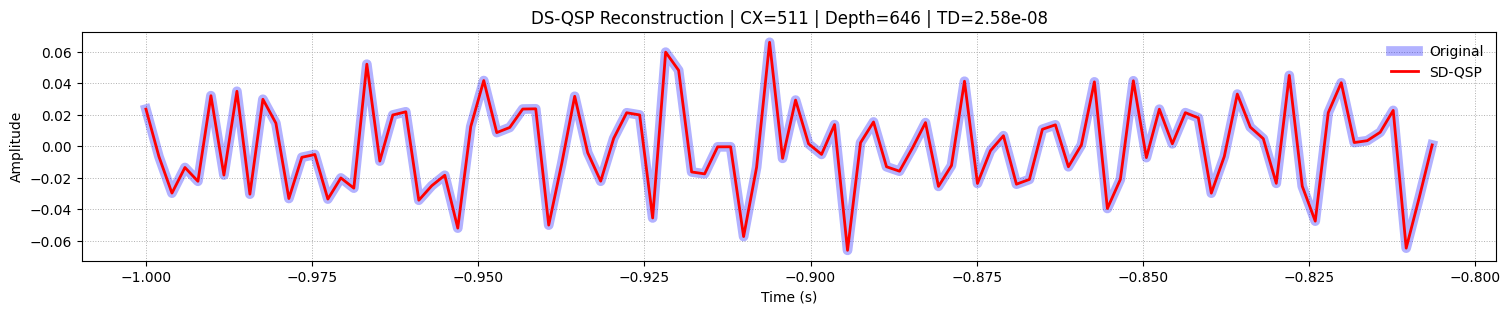

In [35]:
# Your existing time and signals
plt.figure(figsize=(15,3))  # smaller height for paper

# Plot original (thicker)
plt.plot(t[:100], x_norm[:100], label="Original", color='blue', lw=7, alpha=0.3)

# Plot reconstructed (dashed, slightly thinner)
plt.plot(t[:100], x_rec[:100], label="SD-QSP", linewidth=2, color="red")
plt.title(
    rf"DS-QSP Reconstruction | CX=511 | Depth=646 | TD={D:.2e}"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, linestyle=':', linewidth=0.7)

# Add legend (best location based on content)
plt.legend(loc='upper right', frameon=False)

# Tidy up layout
plt.tight_layout(pad=0.2)

# Optional save for LaTeX
plt.savefig("../figures/Sparse-Periodic_dsqsp.pdf")


plt.show()

## Quantum Reconstruction via the Inverse Quantum Fourier Transform}

In [25]:
from qibo import Circuit, gates
from qibo.models import QFT
from qibo.models.encodings import sparse_encoder
from qibo.ui import plot_circuit

In [16]:
# Parameters
A = 0.4109974683
B = 0.5753964556
theta = np.arccos(np.sqrt(2)*A)  # such that cosθ = sqrt(2) A, sinθ = sqrt(2) B

In [28]:
from qibo import Circuit, gates

# Sparse transform-domain coefficient vector
vec = X_norm

# Indices of nonzero coefficients
nz = np.flatnonzero(vec)

# Number of qubits required for amplitude encoding
nqubits = int(np.log2(len(vec)))

# Construct sparse basis-state representation
# as (bitstring, amplitude) pairs
y = [
    (format(i, f"0{nqubits}b"), vec[i])
    for i in nz
]

# Prepare sparse quantum state using
# the Farias sparse state preparation method
qc = sparse_encoder(
    y,
    method="farias"
)

# ------------------------------------------------
# inverse QFT
# ------------------------------------------------
iqft = QFT(nqubits=n).invert()

qc.add(iqft.on_qubits(0,1,2,3,4,5,6,7,8,9))


print(qc.decompose().decompose().summary())

Circuit depth = 646
Total number of gates = 1161
Number of qubits = 10
Most common gates:
cx: 511
x: 338
rz: 211
ry: 91
h: 10
None


(<Axes: >, <Figure size 780x480 with 1 Axes>)

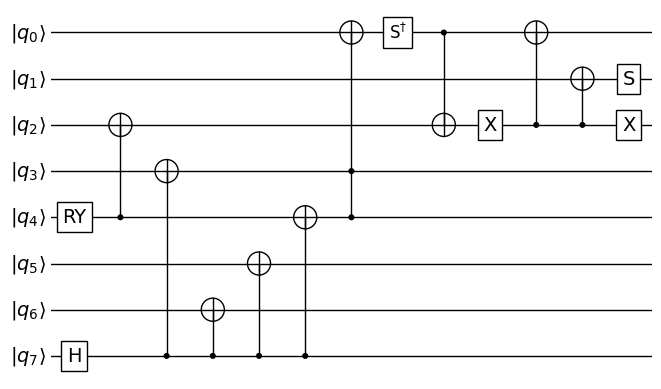

In [18]:
plot_circuit(qc)

### Statevector of the Quantum SQSP and Quantum Decompression

In [19]:
result = qc()

state = result.state()

[Qibo 0.3.5|INFO|2026-07-26 18:37:02]: Using numpy backend on /CPU:0


In [20]:
td = trace_distance(target_f, state)

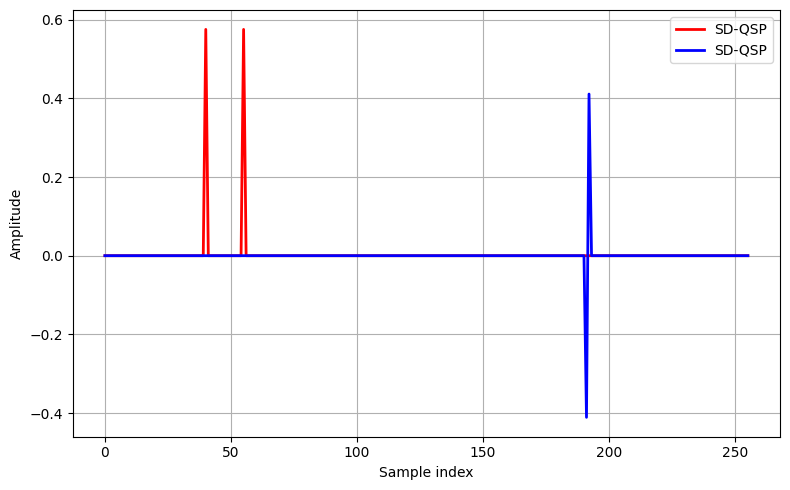

In [21]:
plt.figure(figsize=(8, 5))
#plt.plot(target_f, 'blue', lw=7, alpha=0.3, label="Target")
plt.plot(state.real, lw=2, color="red", label="SD-QSP")
plt.plot(state.imag, lw=2, color="blue", label="SD-QSP")
#plt.title(f"Sinc | thr-k={k} |  TD={td:.4e}")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.savefig("../figures/Sinc_signal_DFT.pdf")
plt.show()